# Title = E-Commerce Delivery Analytics

## Project Overview

### This project performs Exploratory Data Analysis (EDA) on an e-commerce delivery dataset to understand factors affecting delivery performance, customer satisfaction, refund requests, and order value patterns.
### The analysis uses Python to explore delivery delays, platform performance, and product category trends to generate insights that could help improve operational efficiency and customer experience.

# Business Questions

## This analysis aims to answer the following key business questions:

### 1) Which delivery platform processes the highest number of transactions?
### 2) Is delivery delay associated with a higher probability of refund requests?
### 3) Which product categories experience the highest number of refund requests?
### 4) Which product categories generate the highest total order value?
### 5) Which operational factors (such as delivery time or delay) have the greatest impact on customer service ratings?
### 6) Which delivery platform achieves the highest average customer service ratings?

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sn

# Exploratory Data Analysis

In [2]:
#Reading Data
data = pd.read_csv('Ecommerce_Delivery_Analytics_New.csv')

In [3]:
#Exploring data
data.head(10) # We have 100000 Rows and 11 Columns

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No
5,ORD000006,CUST3286,Blinkit,36:29.5,25,Personal Care,1939,Items missing from order.,2,No,Yes
6,ORD000007,CUST2679,JioMart,22:29.5,22,Personal Care,1693,"Fast delivery, great service!",5,No,No
7,ORD000008,CUST9935,Swiggy Instamart,50:29.5,16,Personal Care,195,"Horrible experience, never ordering again.",1,No,Yes
8,ORD000009,CUST2424,JioMart,51:29.5,39,Fruits & Vegetables,182,Very satisfied with the service.,5,No,No
9,ORD000010,CUST7912,JioMart,08:29.5,51,Grocery,1279,"Very late delivery, not happy.",2,Yes,Yes


In [4]:
data.tail()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
99995,ORD099996,CUST5324,JioMart,49:29.5,24,Dairy,289,Packaging could be better.,3,No,No
99996,ORD099997,CUST1677,JioMart,18:29.5,19,Snacks,322,Good quality products.,4,No,No
99997,ORD099998,CUST8198,JioMart,27:29.5,41,Dairy,135,"Fast delivery, great service!",5,Yes,No
99998,ORD099999,CUST9975,JioMart,14:29.5,31,Grocery,973,Quick and reliable!,5,No,No
99999,ORD100000,CUST3748,JioMart,41:29.5,34,Fruits & Vegetables,453,Packaging could be better.,3,No,No


In [5]:
#statistical Exploration of Data 
data.describe()

,Delivery Time (Minutes),Order Value (INR),Service Rating
count,100000.000000,100000.000000,100000.000000
mean,29.536140,590.994400,3.240790
std,9.958933,417.409058,1.575962
min,5.000000,50.000000,1.000000
25%,23.000000,283.000000,2.000000
50%,30.000000,481.000000,3.000000
75%,36.000000,770.000000,5.000000
max,76.000000,2000.000000,5.000000


In [6]:
data.info() 
#No nulls Values in the data . So Data Cleaning not needed . 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Order Date & Time        100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


In [7]:
data.isnull().sum() # No Null Values

Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

In [8]:
# Renaming Column
data= data.rename(columns = {'Delivery Time (Minutes)':'Delivery Time'})

In [9]:
data.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time,Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


# Problem Statement Analysis

## Question 1 - Which delivery platform processes the highest number of transactions?

### Analysis

In [12]:
count=data.groupby('Platform')['Service Rating'].count().sort_values(ascending = False)
count


Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: Service Rating, dtype: int64

### Visualization

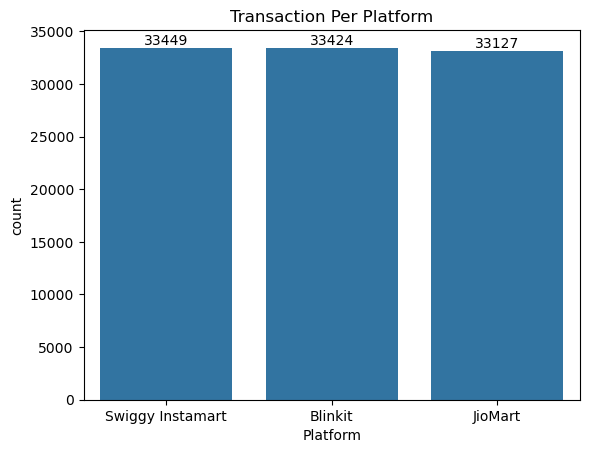

In [17]:
ax = sn.countplot(x="Platform", data=data,order = count.index)
for container in ax.containers: # Adding labels 
    ax.bar_label(container)
pt.title("Transaction Per Platform")
pt.show()

## Observation

### Swiggy Instamart processes the highest number of transactions compared to other platforms.

## Insight

### Swiggy Instamart likely has greater customer reach or operational efficiency compared to competitors.

## Business Recommendation

### The company could analyze the operational and marketing strategies of Swiggy Instamart to improve performance across other platforms.

## Question 2 - Is delivery delay associated with higher refund probability?

## Visualization

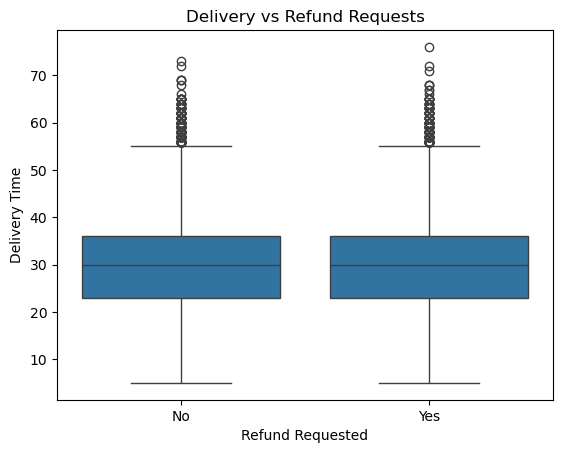

In [14]:
sn.boxplot(x='Refund Requested',y ='Delivery Time',data=data)
pt.title('Delivery vs Refund Requests')
pt.show()

## Observation

### Orders that requested refunds has almost same delivery time as for those which has not requested refunds

## Insight

### Delivery delays appear to have no or very less contribution in customer dissatisfaction and refund requests.

## Recommendation

### Since delivery time does not significantly influence refund requests, the company should focus on product quality, service experience, and category level issues to reduce refund rates.

## Question 3 - Which product category gets most refund request ?

## Analysis

In [15]:
refund_requested = data[data['Refund Requested'] == 'Yes']
sort = refund_requested['Product Category'].value_counts().sort_values(ascending = False) # Giving count of refunds of each Product Category
sort


Product Category
Grocery                7811
Fruits & Vegetables    7692
Dairy                  7691
Snacks                 7559
Beverages              7549
Personal Care          7517
Name: count, dtype: int64

## Visualization

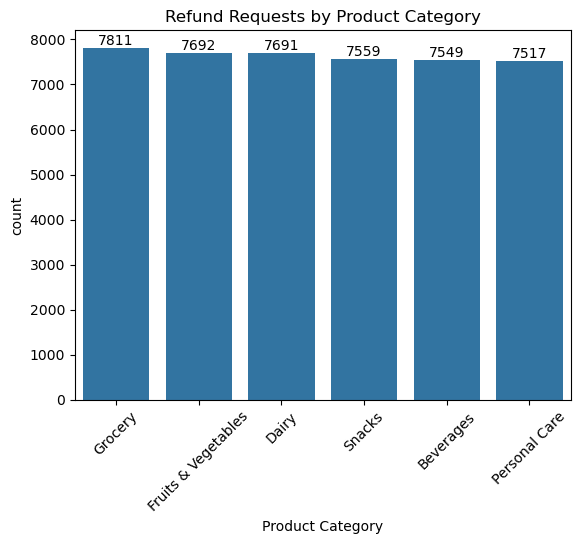

In [18]:
a = sn.countplot(x = 'Product Category',data = refund_requested,order = sort.index)
for container in a.containers:
    a.bar_label(container)
pt.title('Refund Requests by Product Category')
pt.xticks(rotation=45) #Rotating x axis Values to 45 For clear Identification
pt.show()

## Observation
### Grocery has the highest amount of refund request.
## Insight
### Grocery orders may be more prone to quality or delivery-related issues.
## Recommendation
### Improve quality checks and packaging for perishable items like grocery , Fruits , Dairy orders to reduce refunds.

## Question 4 -  Which Products Category generate Highest Order Value ?

## Analysis

In [19]:
order=data.groupby('Product Category')['Order Value (INR)'].sum().sort_values(ascending = False)
order

Product Category
Personal Care          17395601
Grocery                14194055
Beverages               9086669
Dairy                   7610522
Fruits & Vegetables     6246517
Snacks                  4566076
Name: Order Value (INR), dtype: int64

## Visualization

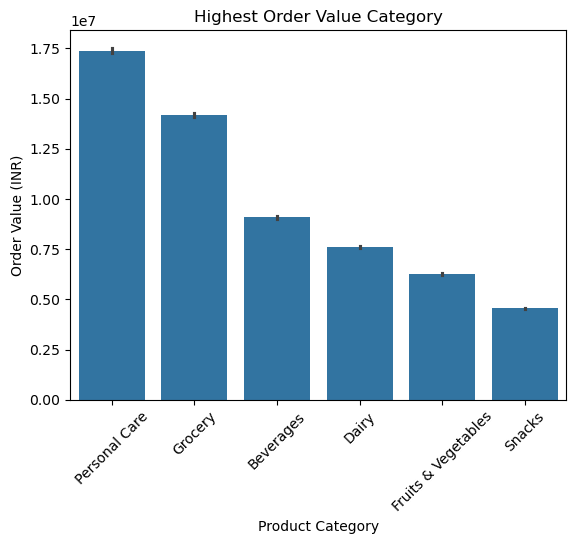

In [20]:
ax=sn.barplot(x='Product Category',y='Order Value (INR)',data = data, estimator=sum,order=order.index)
pt.title('Highest Order Value Category')
pt.xticks(rotation=45)
pt.show()


## Observation

### Personal Care generates the highest total order value, followed by Grocery and Beverages.

## Insight

### Customers spend more on Personal Care and Grocery products, making them the primary value driving categories.

## Business Recommendation

### Focus promotions and inventory optimization on high value categories to maximize sales potential.

## Question 5 - Which Factor Impacts Customer Rating the Most?

## Visualization

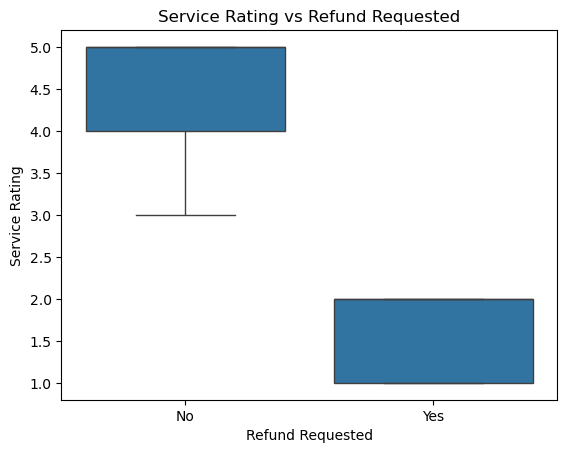

In [24]:
sn.boxplot(x='Refund Requested',y='Service Rating',data = data)
pt.title("Service Rating vs Refund Requested")
pt.show()

## Observation

### Orders with refund requests tend to receive significantly lower service ratings.

## Insight

### Refund requests are strongly associated with lower customer satisfaction.

## Business Recommendation

### Reducing operational issues that lead to refunds could improve overall customer ratings.

## Question 6 -  Which delivery platform achieves the highest average customer service ratings?¶

## Analysis

In [26]:

rating = data.groupby('Platform')['Service Rating'].mean().sort_values(ascending = False)
rating

Platform
JioMart             3.245147
Swiggy Instamart    3.243415
Blinkit             3.233844
Name: Service Rating, dtype: float64

## Visualization

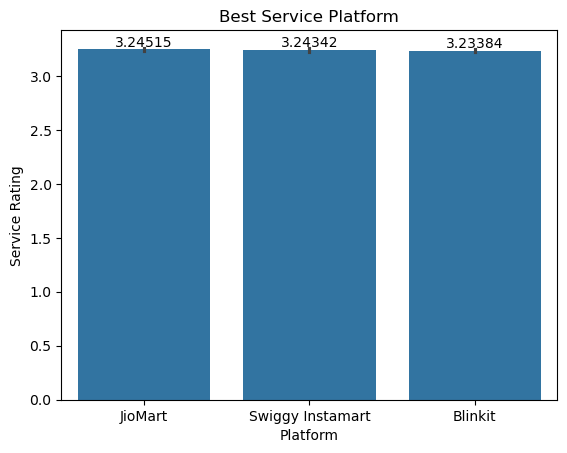

In [28]:
ax = sn.barplot(x='Platform',y = 'Service Rating',data = data , order = rating.index)
for container in ax.containers:
    ax.bar_label(container)
pt.title('Best Service Platform')    
pt.show()

## Observation

###  JioMart has the highest average ratings, followed closely by Swiggy Instamart and Blinkit.

## Insight

### JioMart appears to deliver slightly better customer service experiences.

## Business Recommendation

### Analyze JioMart operational practices to identify factors contributing to higher customer satisfaction.

# Key Insights



## Personal Care and Grocery categories generate the highest total order value, indicating stronger customer spending in these segments.

## Grocery category records the highest number of refund requests, suggesting potential operational or product quality issues.

## Orders associated with refunds show significantly lower service ratings, indicating a strong link between refund cases and customer dissatisfaction.

## JioMart appears to have best average delivery ratings, although performance across platforms remains relatively close.